# Ultimatum Game Analysis

4 personas (normal / strategic / greedy / benevolent) x 500 runs

In [1]:
import pathlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

RESULTS_DIR = pathlib.Path("../results/ultimatum")
FIGURES_DIR = pathlib.Path("figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PERSONAS = ["normal", "strategic", "greedy", "benevolent"]
MODEL = "gpt-5-mini"

dfs = []
for persona in PERSONAS:
    path = RESULTS_DIR / persona / MODEL / "ultimatum_1.csv"
    if path.exists():
        dfs.append(pd.read_csv(path))
    else:
        print(f"Not found: {path}")

df = pd.concat(dfs, ignore_index=True)
print(f"Total rows: {len(df)}")
df.head()

Total rows: 2000


,persona,region,name,age,gender,occupation,offer,reason
0,normal,Oceania,Aroha Te Rangi,39,Female,Environmental Policy Advisor,30,As a 39-year-old environmental policy advisor ...
1,normal,East Asia,Keiko Tanaka,68,Female,Retired elementary school teacher,50,As a retired elementary school teacher I value...
2,normal,East Asia,Yumi Tanaka,43,Female,Hospital Pharmacist,40,"As a 43-year-old hospital pharmacist, I value ..."
3,normal,Africa,Kwame Mensah,31,Male,Civil Engineer,30,"As Kwame Mensah (31, civil engineer), I want a..."
4,normal,Middle East,Lina Al-Hassan,20,Female,Computer Science undergraduate and part-time j...,30,As a 20-year-old CS student and part-time juni...


In [2]:
# Summary statistics by persona
df.groupby("persona")["offer"].describe()

,count,mean,std,min,25%,50%,75%,max
persona,,,,,,,,
benevolent,500.0,50.18,3.548632,35.0,50.0,50.0,50.0,90.0
greedy,500.0,13.08,7.234520,1.0,10.0,15.0,20.0,25.0
normal,500.0,36.02,7.666626,20.0,30.0,30.0,40.0,60.0
strategic,500.0,30.12,3.862050,20.0,30.0,30.0,30.0,50.0


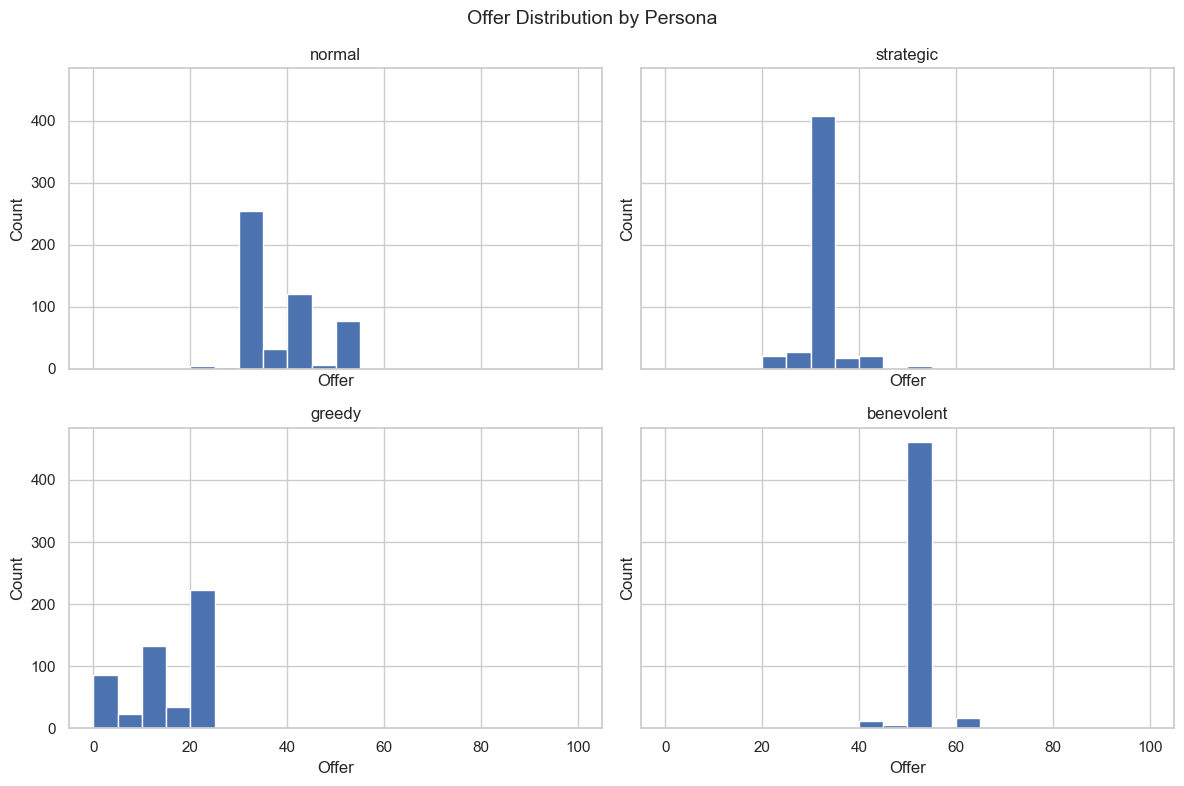

In [3]:
# Offer distribution by persona (histogram)
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
for ax, persona in zip(axes.flat, PERSONAS):
    subset = df[df["persona"] == persona]["offer"]
    ax.hist(subset, bins=range(0, 105, 5), edgecolor="white")
    ax.set_title(persona)
    ax.set_xlabel("Offer")
    ax.set_ylabel("Count")
fig.suptitle("Offer Distribution by Persona", fontsize=14)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "offer_distribution_by_persona.png", dpi=150)
plt.show()

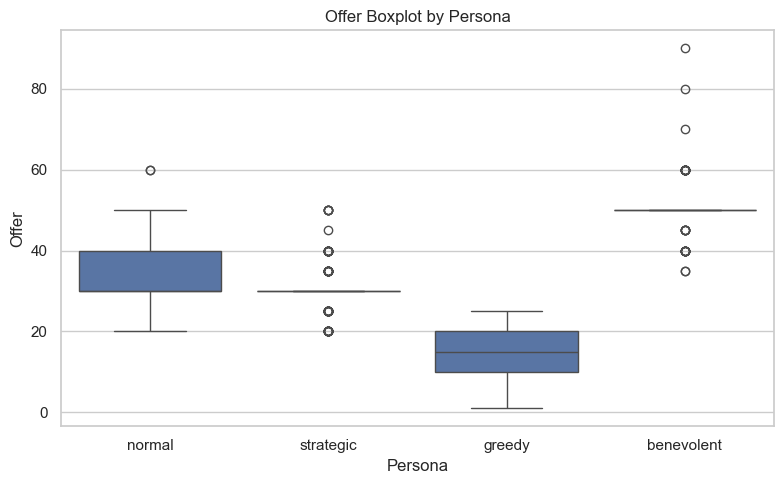

In [4]:
# Boxplot by persona
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="persona", y="offer", order=PERSONAS, ax=ax)
ax.set_title("Offer Boxplot by Persona")
ax.set_xlabel("Persona")
ax.set_ylabel("Offer")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "offer_boxplot_by_persona.png", dpi=150)
plt.show()

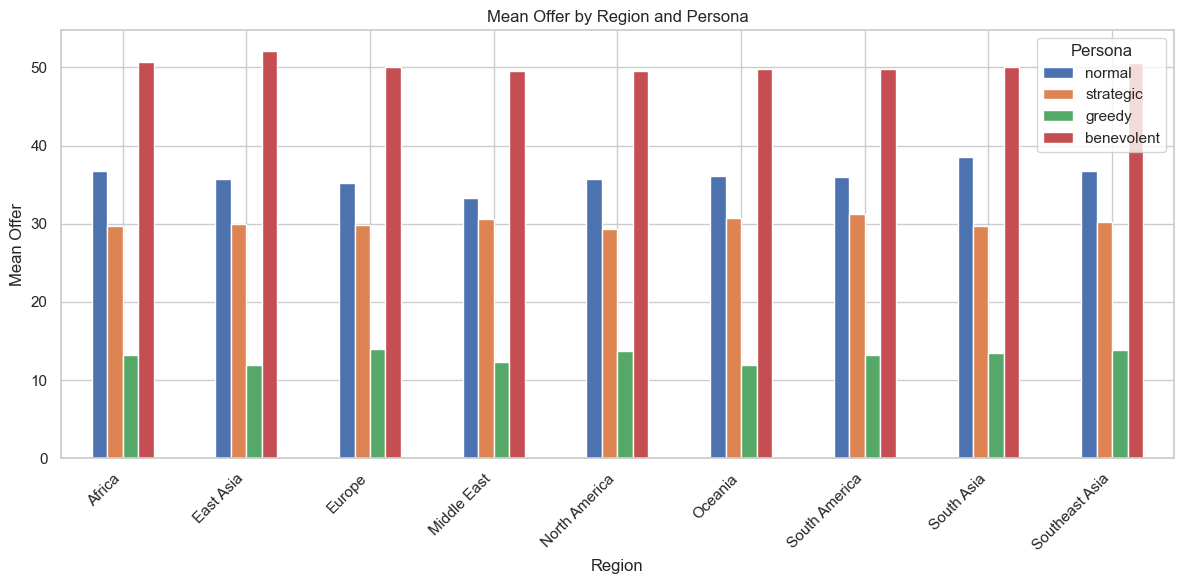

In [5]:
# Mean offer by region
region_mean = df.groupby(["region", "persona"])["offer"].mean().unstack()
fig, ax = plt.subplots(figsize=(12, 6))
region_mean[PERSONAS].plot(kind="bar", ax=ax)
ax.set_title("Mean Offer by Region and Persona")
ax.set_xlabel("Region")
ax.set_ylabel("Mean Offer")
ax.legend(title="Persona")
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "offer_by_region.png", dpi=150)
plt.show()

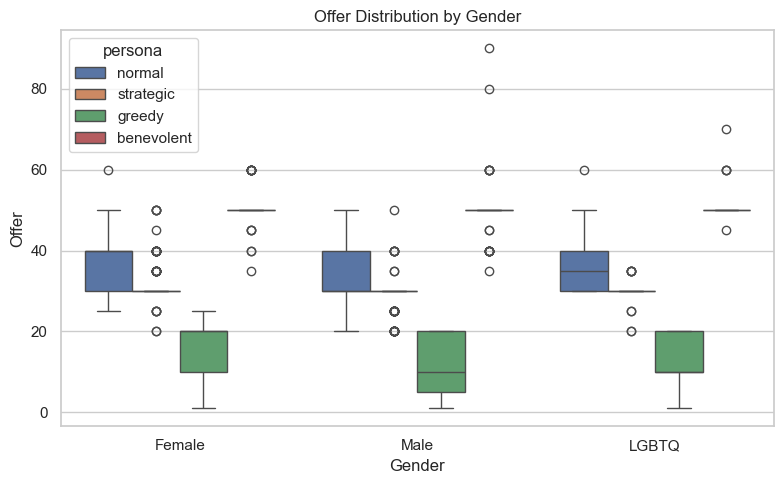

In [6]:
# Offer distribution by gender
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="gender", y="offer", hue="persona", hue_order=PERSONAS, ax=ax)
ax.set_title("Offer Distribution by Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Offer")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "offer_by_gender.png", dpi=150)
plt.show()

In [ ]:
# Age vs Offer scatter plot
fig, ax = plt.subplots(figsize=(10, 6))
for persona in PERSONAS:
    subset = df[df["persona"] == persona]
    ax.scatter(subset["age"], subset["offer"], alpha=0.3, label=persona, s=15)
ax.set_title("Age vs Offer")
ax.set_xlabel("Age")
ax.set_ylabel("Offer")
ax.legend(title="Persona")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "offer_by_age.png", dpi=150)
plt.show()

In [ ]:
# Mean offer by occupation (top 15)
TOP_N = 15
top_occupations = df["occupation"].value_counts().head(TOP_N).index
df_top = df[df["occupation"].isin(top_occupations)]

occ_mean = df_top.groupby("occupation")["offer"].mean().sort_values()
fig, ax = plt.subplots(figsize=(10, 7))
occ_mean.plot(kind="barh", ax=ax)
ax.set_title(f"Mean Offer by Occupation (Top {TOP_N})")
ax.set_xlabel("Mean Offer")
ax.set_ylabel("Occupation")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "offer_by_occupation.png", dpi=150)
plt.show()